In [6]:
import pandas as pd 
import numpy as np
import sqlite3 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. EDA
In this part, we will

In [7]:
root_dir = "../data/"
returns = pd.read_csv(root_dir + "returns.csv")
geography = pd.read_csv(root_dir + "geography.csv")
inventory = pd.read_csv(root_dir + "inventory.csv")
order_items = pd.read_csv(root_dir + "order_items.csv")
orders = pd.read_csv(root_dir + "orders.csv")
payments = pd.read_csv(root_dir + "payments.csv")
products = pd.read_csv(root_dir + "products.csv")
promotions = pd.read_csv(root_dir + "promotions.csv")
reviews = pd.read_csv(root_dir + "reviews.csv")
sales = pd.read_csv(root_dir + "sales.csv", parse_dates=["Date"])
sample_submission = pd.read_csv(root_dir + "sample_submission.csv")
shipments = pd.read_csv(root_dir + "shipments.csv")
web_traffic = pd.read_csv(root_dir + "web_traffic.csv")
customers = pd.read_csv(root_dir + "customers.csv")


In [8]:
target_prediction = sales[['Revenue', 'COGS']]

- The target prediction is revenue and cost of good sold
- We will do many trial and errors between different features so we can examine what is the most relevant features to target prediction

### Revenue performance

### 1. Descriptive analysis
- In this part, we will see the trend of revenue, and judge the business operation performance overtime.
- Trong phần 1, chúng ta sẽ nhìn xu hướng biểu đồ doanh thu, và đánh giá hiệu suất vận hành doanh nghiệp qua thời gian.

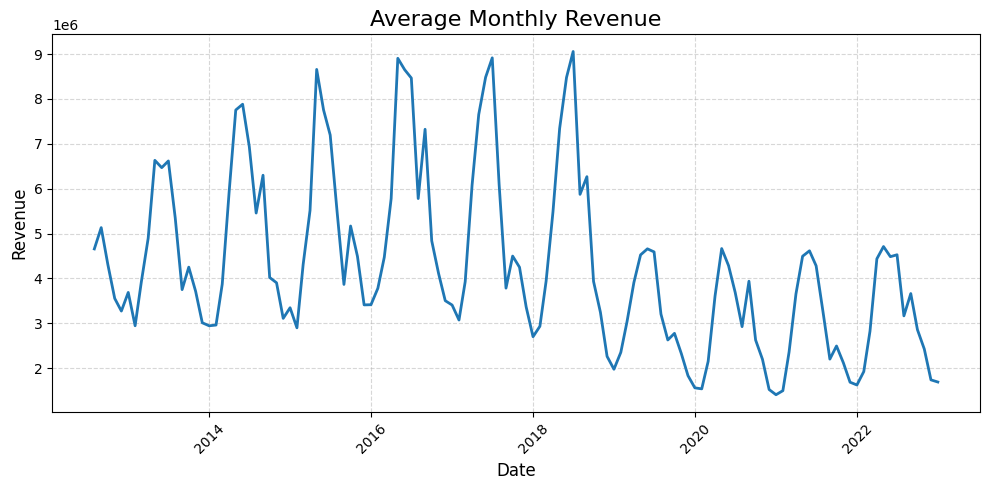

In [9]:
import matplotlib.pyplot as plt

avgRev = sales.set_index("Date").resample("M").mean()

plt.figure(figsize=(10, 5))

plt.plot(
    avgRev.index,
    avgRev["Revenue"],
    linewidth=2
)

plt.title("Average Monthly Revenue", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

- Revenue peaks just before 2019 and then declines significantly, dropping by roughly 40–60% in subsequent years.
- Doanh thu sau khi đạt đỉnh vào năm 2019, thì đột ngột giảm mạnh khoảng 40-60% vào những năm tiếp theo.

### 2. Diagnostic

- In this part, we will examine why revenue declined significantly. While we know that the COVID-19 pandemic occurred in 2019, we also want to explore other contributing factors to better inform decisions and improve performance.
- Trong phần này, chúng ta sẽ phân tích lý do tại sao doanh thu giảm đáng kể. Mặc dù chúng ta biết rằng đại dịch COVID-19 xảy ra vào năm 2019, chúng ta cũng muốn tìm hiểu thêm các yếu tố ảnh hưởng khác để đưa ra quyết định tốt hơn và cải thiện hiệu suất.

In [11]:
rev_ana = order_items[["order_id", "quantity", "unit_price"]]
rev_ana["revenue"] = rev_ana["quantity"] * rev_ana["unit_price"]
# rev_ana = merge(orders[["custo    mer_id", "order_id"]], on="order_id")
rev_ana = rev_ana.groupby("order_id")["revenue"].sum().to_frame().reset_index()
rev_ana = orders[["order_date", "order_id", "customer_id"]].merge(rev_ana, on="order_id")
rev_ana["order_date"] = pd.to_datetime(rev_ana["order_date"])

rev_ana["year"] = rev_ana["order_date"].dt.year

analysis = rev_ana.groupby("year").agg(
    revenue=("revenue", "sum"),
    orders=("order_id", "nunique"),
    customers=("customer_id", "nunique")
)

analysis["avg_order_value"] = analysis["revenue"] / analysis["orders"]
analysis["orders_per_customer"] = analysis["orders"] / analysis["customers"]

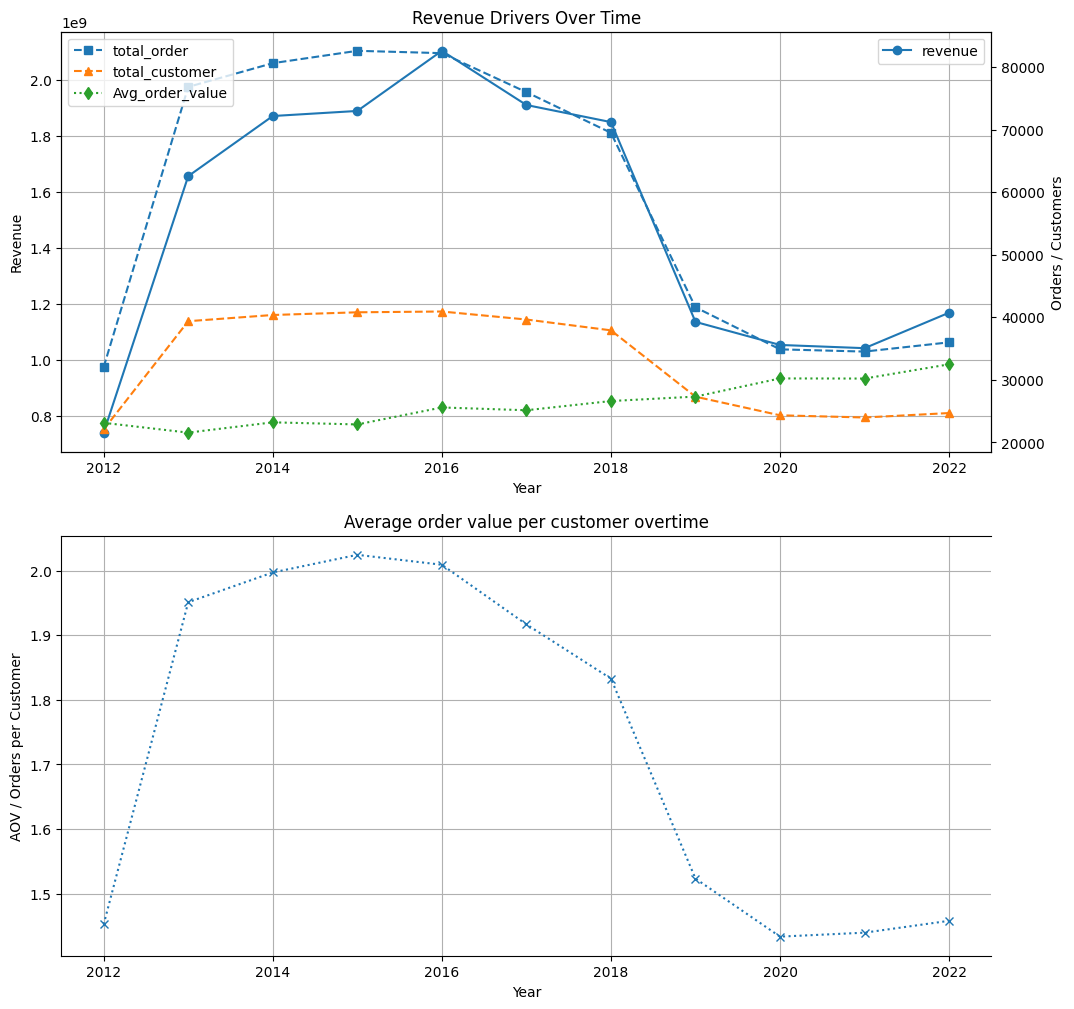

In [15]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(2, 1, figsize=(12, 12))

# Revenue (primary axis)
ax1[0].plot(analysis.index, analysis["revenue"], marker='o', label="revenue")
ax1[0].set_xlabel("Year")
ax1[0].set_ylabel("Revenue")

# Second axis (orders & customers)
ax2 = ax1[0].twinx()
ax2.plot(analysis.index, analysis["orders"], linestyle='--', marker='s', label="total_order")
ax2.plot(analysis.index, analysis["customers"], linestyle='--', marker='^', label="total_customer")
ax2.set_ylabel("Orders / Customers")

# Third axis (AOV & frequency)
ax3 = ax1[1]
ax3.spines["right"].set_position(("outward", 60))  # shift axis
ax2.plot(analysis.index, analysis["avg_order_value"], linestyle=':', marker='d', label="Avg_order_value")
ax3.plot(analysis.index, analysis["orders_per_customer"], linestyle=':', marker='x')
ax3.set_ylabel("AOV / Orders per Customer")

# Title & grid
plt.title("Revenue Drivers Over Time")
ax1[0].legend()
ax2.legend(loc="upper left")
# plt.legend()
ax1[0].grid()
ax3.grid()
ax3.set_title("Average order value per customer overtime")
ax3.set_xlabel("Year")

plt.show()

- To analyze the revenue decline, we need to consider two factors: the number of orders and the average order value, using the formula:
- $$Revenue\ =\ Number\ of\ Orders\ \times Average\ Order\ Value$$
  + The average order value stayed stable and even increased (green line)
  + Meanwhile, the number of orders dropped sharply in 2019
- The drop in the number of orders is due to two factors:
  + A decrease in the number of customers
  + A decrease in the number of orders per customer

---

- Để phân tích về sự sụt giảm của revenue chúng ta cần cân nhắc hai yếu tố số lượng đơn hàng và giá trị trung bình mỗi đơn hàng với công thức: 
- $$revenue\ =\ số\ lượng\ đơn\ hàng\ \times giá\ trị\ trung\ bình\ mỗi\ đơn\ hàng$$
  + Giá trị trung bình đơn hàng không đổi thậm chí còn tăng (đường màu xanh lá cây)
  + Trong khi số lượng đơn hàng giảm kỉ lục trong năm 2019

- Sự sụt giảm về số lượng đơn hàng do hai yếu tố:
    + Sự sụt giảm về số lượng khách hàng
    + Sự sụt giảm về số lượng đơn hàng của mỗi khách hàng 

- Analysis of why the number of customers decreased:

    + The number of new customers each year (customer acquisition ability)
    + The ability to retain existing customers (whether churn happens frequently and why)
---

- Phân tích về việc tại sao khách hàng lại giảm:
    + Số lượng khách hàng mới qua mỗi năm (customer acquisition ability)
    + Khả năng giữ chân khách hàng cũ (liệu việc churn có xảy ra thường xuyên không vì sao)

### 2.1 User Acquisition Analysis

In [16]:
order_items["revenue"] = order_items["quantity"] * order_items["unit_price"]
channel_analysis = order_items.groupby("order_id")["revenue"].sum().to_frame().reset_index()
channel_analysis = channel_analysis.merge(orders, on="order_id")
channel_analysis.sort_values(by="order_date", inplace=True)


first_orders = (
    channel_analysis.groupby("customer_id")
    .first()
    .reset_index()
)

first_orders["year"] = pd.to_datetime(first_orders["order_date"]).dt.year

acquisition = (
    first_orders
    .groupby(["year", "order_source"])
    .size()
    .reset_index(name="new_customers")
)

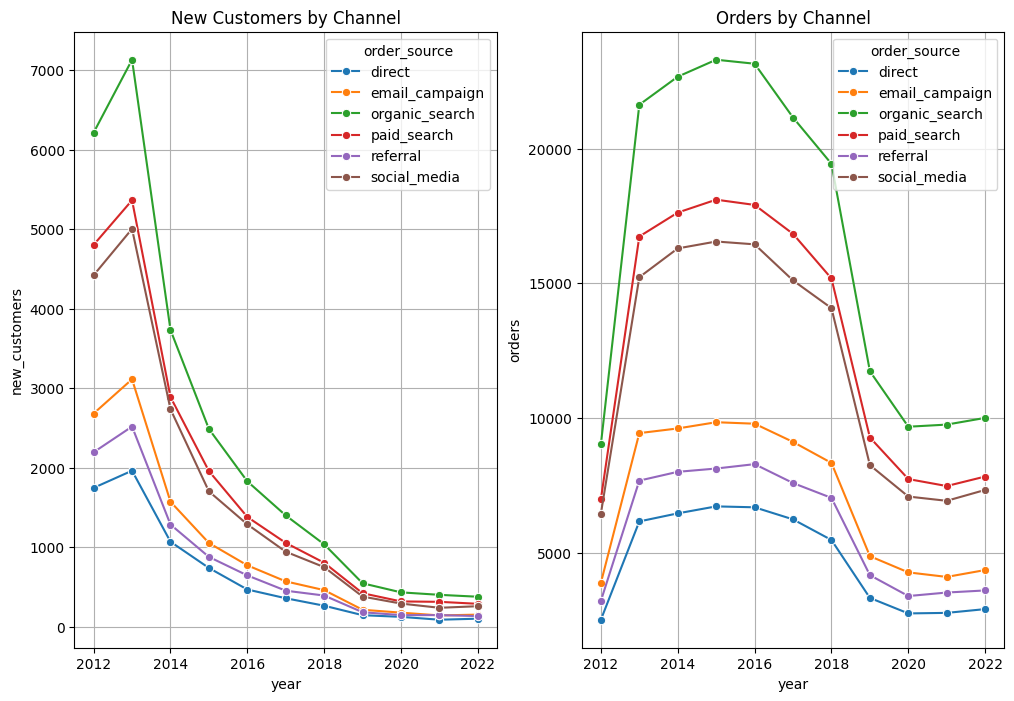

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 8))


sns.lineplot(data=acquisition, x="year", y="new_customers", hue="order_source", marker="o", ax=axes[0])
axes[0].set_title("New Customers by Channel")
axes[0].grid()

channel_analysis["year"] = pd.to_datetime(channel_analysis["order_date"]).dt.year
orders_channel = (
    channel_analysis.groupby(["year", "order_source"])["order_id"]
    .count()
    .reset_index(name="orders")
)
sns.lineplot(data=orders_channel, x="year", y="orders", hue="order_source", marker="o", ax=axes[1])
axes[1].set_title("Orders by Channel")
axes[1].grid()
plt.show()

- New customer acquisition declined significantly after 2013–2014 and remained very low after COVID, indicating weak growth in new users. 
- Organic search is the main channel, suggesting customers mostly come when they already have demand, while marketing channels like email and paid search are not strong enough to drive growth. 

=> Overall, the business relies heavily on existing customers and passive demand rather than actively acquiring new customers.

---

- Số lượng khách hàng mới giảm mạnh sau giai đoạn 2013–2014 và duy trì ở mức rất thấp sau COVID, cho thấy khả năng tăng trưởng khách hàng mới yếu. 
- Organic search là kênh chính, cho thấy khách hàng chủ yếu tìm đến khi đã có nhu cầu, trong khi các kênh marketing như email và paid search chưa đủ mạnh để thúc đẩy tăng trưởng. 

=> Nhìn chung, doanh nghiệp phụ thuộc nhiều vào khách hàng hiện tại và nhu cầu thụ động thay vì chủ động thu hút khách hàng mới.

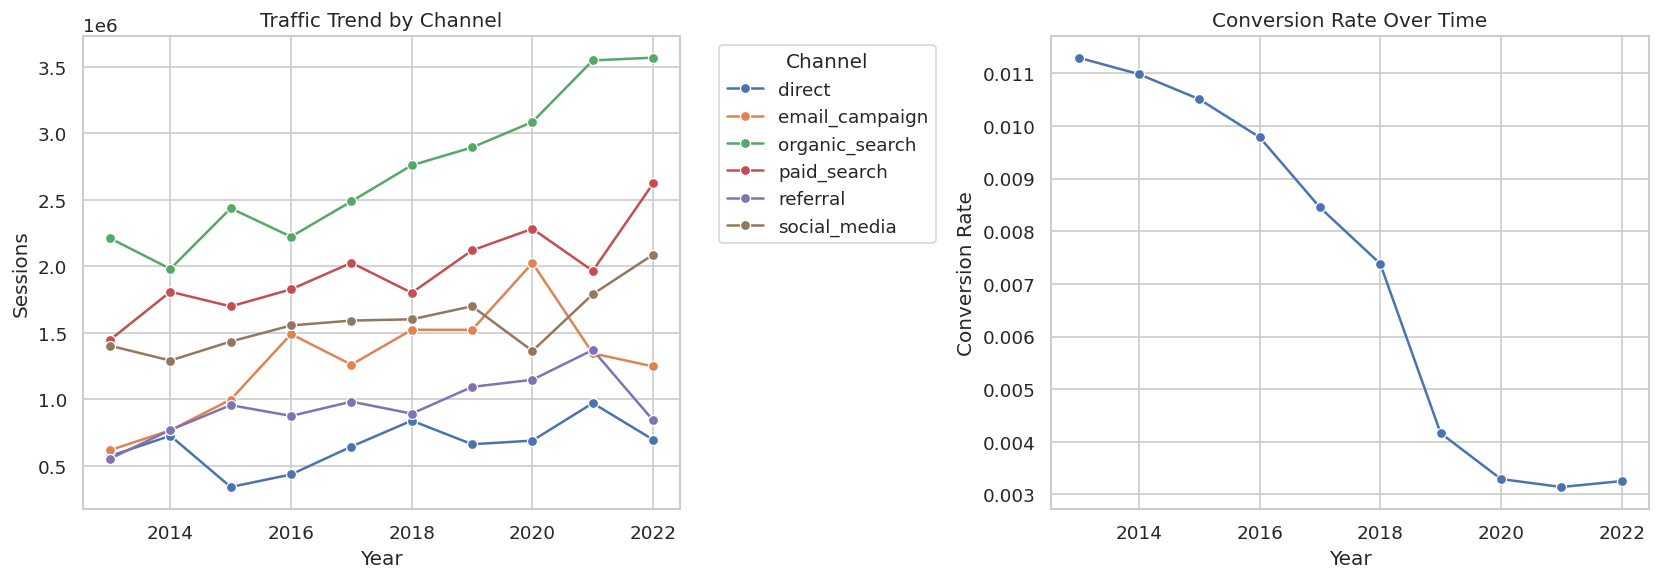

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# Prepare data
web_traffic["year"] = pd.to_datetime(web_traffic["date"]).dt.year
orders["year"] = pd.to_datetime(orders["order_date"]).dt.year

# Traffic trend
traffic_trend = (
    web_traffic.groupby(["year", "traffic_source"])["sessions"]
    .sum()
    .reset_index()
)

# Conversion rate
cv = web_traffic.groupby('year')["sessions"].sum().to_frame()
orders_cv = orders.groupby("year")["order_id"].count()
cv = cv.join(orders_cv, how="left").rename(columns={"order_id": "orders"})
cv["cv_rate"] = cv["orders"] / cv["sessions"]
cv = cv.reset_index()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Traffic by channel
sns.lineplot(
    data=traffic_trend,
    x="year",
    y="sessions",
    hue="traffic_source",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Traffic Trend by Channel", fontsize=12)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Sessions")
axes[0].legend(title="Channel", bbox_to_anchor=(1.05, 1), loc="upper left")

# Right: Conversion rate
sns.lineplot(
    data=cv,
    x="year",
    y="cv_rate",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Conversion Rate Over Time", fontsize=12)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Conversion Rate")
axes[1].ticklabel_format(style='plain', axis='y')

# Layout
plt.tight_layout()
plt.show()


- Growth Paradox: Traffic is surging, but Conversion Rate (CR) has plummeted by over 70%. The site attracts visitors but fails to generate revenue.

- Root Cause: Poor user experience (UX) and weak website appeal, or customers are finding better value from competitors.

---

- Nghịch lý tăng trưởng: Traffic tăng mạnh nhưng tỷ lệ chuyển đổi (CR) giảm sâu (>70%). Website thu hút được người xem nhưng không giữ được người mua.

- Vấn đề cốt lõi: Trải nghiệm người dùng (UX) kém, không đủ sức thuyết phục hoặc sản phẩm/giá cả đang thua kém đối thủ cạnh tranh.

### 2.2 Retention

In [23]:
channel_analysis["order_date"] = pd.to_datetime(channel_analysis["order_date"])
retention = channel_analysis.sort_values("order_date")

# Cohort = first purchase
retention["cohort"] = retention.groupby("customer_id")["order_date"].transform("min").dt.to_period("Y")

# Order year
retention["order_year"] = retention["order_date"].dt.to_period("Y")

cohort_data = (
    retention.groupby(["cohort", "order_year"])["customer_id"]
    .nunique()
    .reset_index()
)

# cohort size
cohort_size = cohort_data[cohort_data["cohort"] == cohort_data["order_year"]]
cohort_size = cohort_size.set_index("cohort")["customer_id"]

# merge + calculate retention
cohort_data["cohort_size"] = cohort_data["cohort"].map(cohort_size)
cohort_data["retention_rate"] = cohort_data["customer_id"] / cohort_data["cohort_size"]

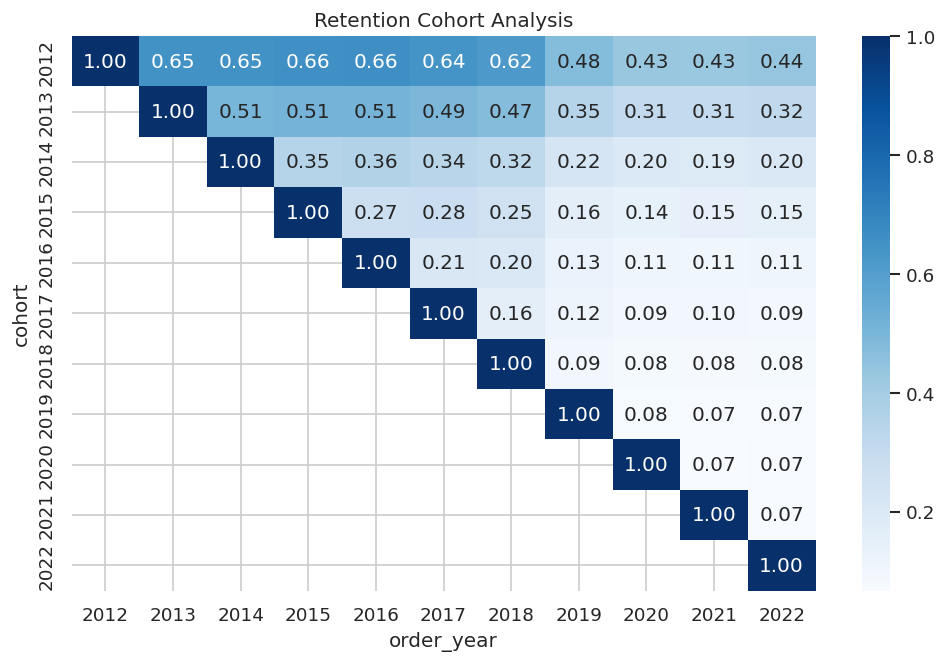

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = cohort_data.pivot(index="cohort", columns="order_year", values="retention_rate")

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Blues")
plt.title("Retention Cohort Analysis")
plt.show()

- Khả năng giữ chân khách hàng mới ngày càng tệ. Các nhóm khách hàng (cohort) từ 2018 trở đi có tỷ lệ quay lại năm thứ hai cực thấp (dưới 10%), so với mức 65% của nhóm năm 2012.
---

- Customer retention is worsening. Cohorts from 2018 onwards have a Year-2 return rate of less than 10%, a sharp drop from the 65% seen in the 2012 cohort.

## 3. Predictive Analysis

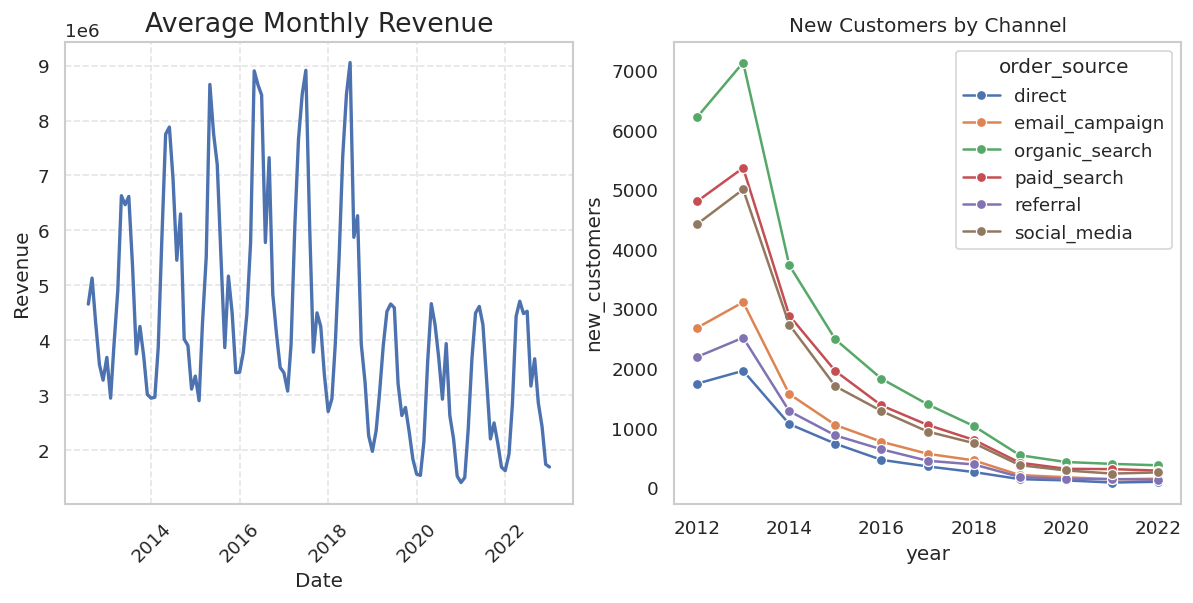

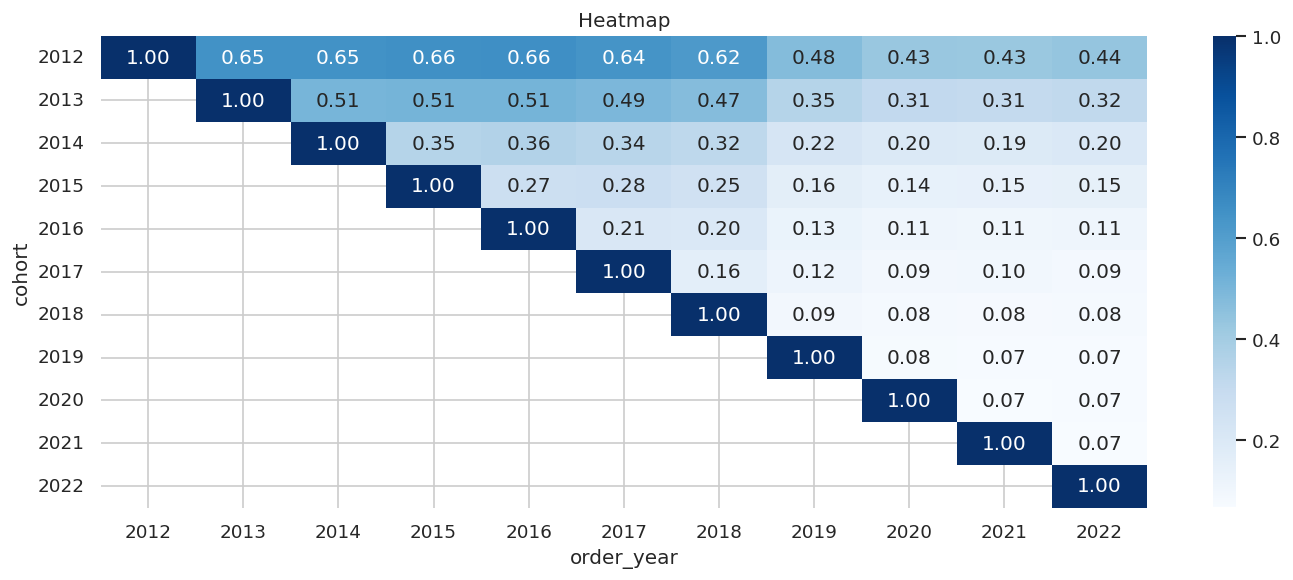

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Average Revenue ---
axes[0].plot(
    avgRev.index,
    avgRev["Revenue"],
    linewidth=2
)
axes[0].set_title("Average Monthly Revenue", fontsize=16)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Revenue")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].tick_params(axis='x', rotation=45)

# --- Plot 2: New Customers by Channel ---
sns.lineplot(
    data=acquisition,
    x="year",
    y="new_customers",
    hue="order_source",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("New Customers by Channel")
axes[1].grid()

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

# --- Plot 3: Heatmap ---
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    ax=ax
)
ax.set_title("Heatmap")

plt.tight_layout()
plt.show()

- In this part, we analyze what will happen if the business continues operating in the same way:
    + The business will struggle to acquire new customers.
    + Existing customers will gradually churn over time.
    + New customers are likely to make only one purchase and not return (as shown by the decline in orders per customer).

=> If no action is taken, revenue will continue to decline significantly due to the shrinking customer base over time.

---

- Trong phần này, chúng ta phân tích điều gì sẽ xảy ra nếu doanh nghiệp tiếp tục hoạt động như hiện tại:
    + Doanh nghiệp gặp khó khăn trong việc thu hút khách hàng mới.
    + Khách hàng hiện tại sẽ dần rời bỏ theo thời gian.
    + Khách hàng mới có xu hướng chỉ mua một lần và không quay lại (thể hiện qua sự giảm số đơn hàng trên mỗi khách hàng).

=> Nếu không có hành động cải thiện, doanh thu sẽ tiếp tục giảm mạnh do tệp khách hàng ngày càng thu hẹp theo thời gian.

## 4. Prescriptive

- To improve the situation, we need to solve two main problems, this is how to acquiring more new customers and increase customer retention.

1. Acquire New Customers
- Scale Paid Marketing (Google Ads, Social Ads)
    + Actively reach new customers instead of relying on organic traffic; use A/B testing to optimize CAC.
    + Metrics: New users, CAC vs LTV
- Referral Program
    + Encourage existing customers to refer others through incentives (e.g., vouchers, discounts).
    + Metrics: % of new users from referral, retention rate by channel
- SEO & Content Strategy (High-intent)
    + Create content based on customer needs and optimize landing pages to improve conversion.
    + Metrics: Organic traffic, conversion rate by page
- Channel Optimization
    + Identify and invest in channels that bring high-quality users.
    + Metrics: LTV by channel, conversion rate
2. Increase Retention
- Lifecycle CRM (Email / Push Notifications)
    + Use behavior-based triggers such as repurchase reminders, reactivation campaigns, and abandoned cart emails.
    + Metrics: Repeat purchase rate, cohort retention
- Loyalty / Rewards Program
    + Offer points or incentives to encourage repeat purchases.
    + Metrics: Orders per customer, LTV
- Improve First Purchase Experience
    + Provide discounts, free shipping, or better onboarding for first-time buyers.
    + Metrics: Second purchase rate
- Personalization
    + Recommend products based on user behavior and purchase history.
    + Metrics: AOV, orders per user
- Churn Detection & Early Intervention
    + Identify at-risk customers and re-engage them early.
    + Metrics: Churn rate, reactivation rate
- Final Takeaway
    + Acquisition drives short-term growth by increasing the number of users.
    + Retention drives long-term growth by increasing customer value.

=> Sustainable growth comes from acquiring the right customers and retaining them effectively.

---

1. Thu hút khách hàng mới

- Mở rộng Paid Marketing (Google Ads, Social Ads)
    + Chủ động tiếp cận khách hàng thay vì phụ thuộc vào organic; sử dụng A/B testing để tối ưu CAC.
    + Chỉ số: Số lượng khách hàng mới, CAC so với LTV
- Chương trình giới thiệu (Referral Program)
    + Khuyến khích khách hàng hiện tại giới thiệu bạn bè thông qua ưu đãi.
    + Chỉ số: Tỷ lệ khách hàng mới từ referral, retention theo kênh
- Chiến lược SEO & Content (theo nhu cầu)
    + Tạo nội dung theo nhu cầu khách hàng và tối ưu landing page để tăng chuyển đổi.
    + Chỉ số: Traffic organic, conversion rate theo trang
- Tối ưu kênh (Channel Optimization)
    + Xác định và tập trung vào các kênh mang lại khách hàng chất lượng cao.
    + Chỉ số: LTV theo kênh, conversion rate
2. Tăng giữ chân khách hàng
- Lifecycle CRM (Email / Push)
    + Gửi thông báo dựa trên hành vi như nhắc mua lại, kích hoạt lại, hoặc giỏ hàng bị bỏ quên.
    + Chỉ số: Tỷ lệ mua lại, retention theo cohort
- Chương trình khách hàng thân thiết (Loyalty Program)
    + Tặng điểm hoặc ưu đãi để khuyến khích khách quay lại.
    + Chỉ số: Số đơn hàng mỗi khách, LTV
- Cải thiện trải nghiệm mua lần đầu
    + Cung cấp giảm giá, miễn phí vận chuyển hoặc onboarding tốt hơn.
    + Chỉ số: Tỷ lệ mua lần hai
- Cá nhân hóa (Personalization)
    + Gợi ý sản phẩm dựa trên hành vi và lịch sử mua hàng.
    + Chỉ số: AOV, số đơn hàng mỗi khách
- Phát hiện churn và can thiệp sớm
    + Xác định khách hàng có nguy cơ rời bỏ và tiếp cận lại kịp thời.
    + Chỉ số: Tỷ lệ churn, tỷ lệ quay lại

- Kết luận
    + Acquisition giúp tăng trưởng ngắn hạn thông qua việc tăng số lượng khách hàng.
    + Retention giúp tăng trưởng dài hạn thông qua việc tăng giá trị mỗi khách hàng.

=> Tăng trưởng bền vững đến từ việc thu hút đúng khách hàng và giữ họ lâu dài.